Notebook to generate the ranking based on the ratio between the model and baseline WIS

In [1]:
import numpy as np 
import pandas as pd 
from aux_func import code_to_state, estado_para_regiao

In [2]:
challenge = 'dengue_state'

df_preds = pd.read_csv(f'./predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [3]:
df_preds.model.unique()

<ArrowStringArray>
[                                       '3rd_imdc_isi_isi-dengue',
                                    '3rd_imdc_purdue_neuralearth',
                                          '3rd_imdc_fiocruz_mard',
                                               '3rd_imdc_bsc_ghr',
                                      '3rd_imdc_fgv_pattern-blue',
                                '3rd_imdc_lncc_lncc_arp26_dengue',
                                        '3rd_imdc_procc_bb_model',
                                         '3rd_imdc_unesp_recogna',
                                '3rd_imdc_ifgw_inframind-proteus',
                                                'DS-OKSTATE-2026',
                              '3rd_imdc_ceri_returnoftheforecast',
                                          '3rd_imdc_nus_nus-cerm',
                             '3rd_imdc_lncc_surge_model26_dengue',
                                     '3rd_imdc_pucrio_arbocaster',
                                           

In [4]:
df_preds.model.unique().shape

(27,)

In [5]:
df_agg_wis = (
    df_preds
    .groupby(["model", "adm_1", "validation"], as_index=False)["wis"]
    .mean()
)


df_agg_wis.head()

,model,adm_1,validation,wis
0,3rd_imdc_-unifesp-_-4mosqueteiras-,11,1,205.38
1,3rd_imdc_-unifesp-_-4mosqueteiras-,11,2,68.46
2,3rd_imdc_-unifesp-_-4mosqueteiras-,11,3,30.97
3,3rd_imdc_-unifesp-_-4mosqueteiras-,11,4,42.33
4,3rd_imdc_-unifesp-_-4mosqueteiras-,12,1,37.72


Gerando um ranking da média da diferença entre os modelos e o baseline: 

In [6]:
model_baseline = '3rd_imdc_procc_bb_model'

df_baseline = (
    df_agg_wis.loc[df_agg_wis["model"] == model_baseline,
           ["adm_1", "validation", "wis"]]
    .rename(columns={"wis": "wis_baseline"})
)

# Junta o WIS do baseline aos demais modelos
df_ratio = df_agg_wis.merge(
    df_baseline,
    on=["adm_1", "validation"],
    how="left"
)

# Razão WIS / Baseline
df_ratio["wis_ratio"] = (
    df_ratio["wis"] / df_ratio["wis_baseline"]
)

# Médias das razões
df_summary = (
    df_ratio
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        arithmetic_mean_ratio=("wis_ratio", "mean"),
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)

df_summary.head()

,adm_1,model,arithmetic_mean_ratio,geometric_mean_ratio
6,11,3rd_imdc_emap_epidematicos_sarimax_state,0.803841,0.769598
20,11,3rd_imdc_pucrio_arbocaster,0.834013,0.789304
16,11,3rd_imdc_lncc_lncc_arp26_dengue,0.818201,0.800598
13,11,3rd_imdc_ifgw_inframind-proteus,0.964784,0.845450
22,11,3rd_imdc_rki_rki_zki_ph,0.914512,0.893327


In [7]:
df_ratio['region'] = df_ratio['adm_1'].replace(code_to_state).replace(estado_para_regiao)

df_ratio.to_csv(f'predictions/rank_ratio_{challenge}.csv', index = False)

np.log(1)

Scatter plot:

In [20]:
import matplotlib.pyplot as plt 
from aux_func import rename_models

In [39]:
df_agg = df_ratio.groupby(['model'])['wis_ratio'].agg(
    mean='mean',
    std='std').reset_index()

df_agg['model'] = df_agg['model'].replace(rename_models)

df_agg = df_agg.loc[df_agg.model != 'PROCC']

df_agg.head()

,model,mean,std
0,UNIFESP,1.596366,0.831712
1,AFYA,2.206032,2.054603
2,BSC,1.384481,1.012681
3,CERI,1.258814,0.642775
4,CORNELL,1.047247,0.351258


In [40]:
df_agg.loc[df_agg['std'] < 0.1]

,model,mean,std


(0.0, 2.0)

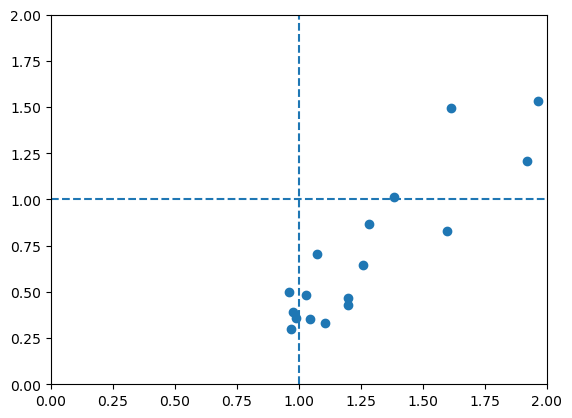

In [41]:
_,ax = plt.subplots()

ax.scatter(df_agg['mean'], df_agg['std'])

ax.axvline(1, linestyle='--')
ax.axhline(1, linestyle='--')

ax.set_ylim([0,2])
ax.set_xlim([0,2])

#ax.set_yscale('log')
#ax.set_xscale('log')

In [29]:
np.log(1)

np.float64(0.0)

In [21]:
np.log(1.1)

np.float64(0.09531017980432493)